In [1]:
#!pip install torch transformers tqdm

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Token indices sequence length is longer than the specified maximum sequence length for this model (1675 > 512). Running this sequence through the model will result in indexing errors
Scoring articles: 100%|██████████| 99/99 [30:35<00:00, 18.54s/it]


Saved sentiment results to ft_salesforce_sentiment.csv


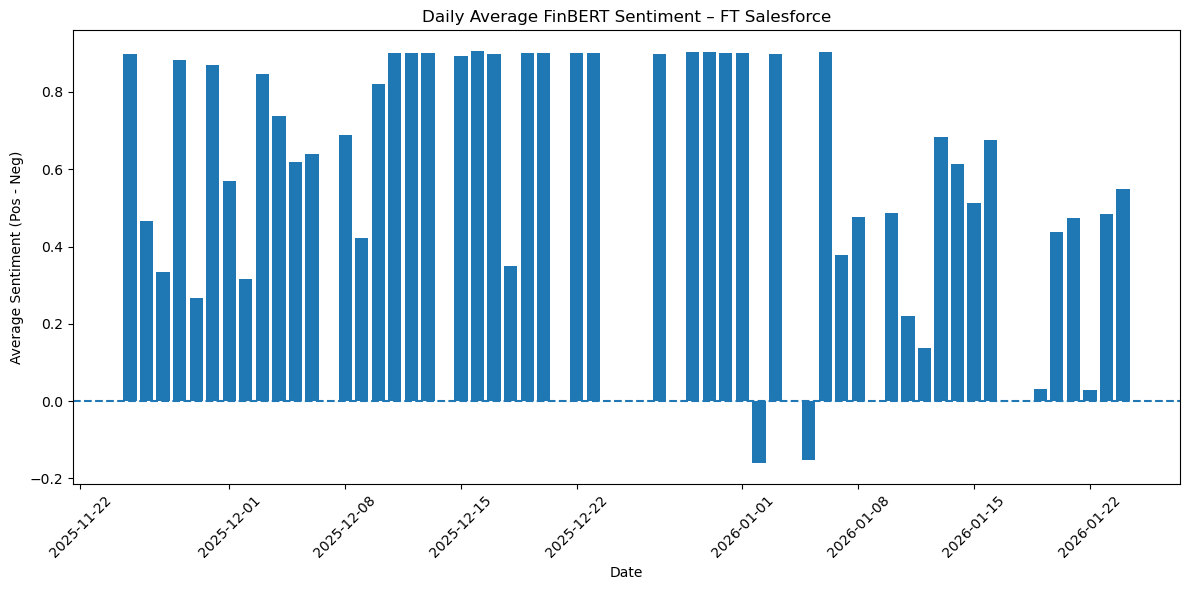

Saved plot to ft_salesforce_daily_sentiment.png


In [2]:
# -*- coding: utf-8 -*-
"""
FinBERT sentiment scoring for FT Nvidia articles
Clean version – no token length warnings, no OpenMP crash
"""

# ----------------------------
# Fix OpenMP duplicate runtime crash (Windows + Anaconda)
# ----------------------------
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# ----------------------------
# Imports
# ----------------------------
import numpy as np
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from tqdm import tqdm
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

# ----------------------------
# Config
# ----------------------------
INPUT_CSV = "ft_salesforce_articles_full.csv"
OUTPUT_CSV = "ft_salesforce_sentiment.csv"
PLOT_PNG = "ft_salesforce_daily_sentiment.png"

MODEL_NAME = "ProsusAI/finbert"
MAX_LEN = 512


# ----------------------------
# Load Data
# ----------------------------
df = pd.read_csv(INPUT_CSV)

if "text" not in df.columns:
    raise ValueError("CSV must contain a 'text' column.")

# Parse date if exists
if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"], errors="coerce")


# ----------------------------
# Load FinBERT
# ----------------------------
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    model_max_length=512
)

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()


# ----------------------------
# Safe Token Chunking (NO re-tokenizing)
# ----------------------------
def get_token_chunks(text, max_len=512):
    ids = tokenizer.encode(str(text), add_special_tokens=False)
    step = max_len - 2  # reserve CLS + SEP
    return [ids[i:i+step] for i in range(0, len(ids), step)]


def score_article(text):
    chunks = get_token_chunks(text, MAX_LEN)

    if len(chunks) == 0:
        return np.array([np.nan, np.nan, np.nan])

    probs_list = []

    for ids in chunks:
        input_ids = [tokenizer.cls_token_id] + ids + [tokenizer.sep_token_id]
        attention_mask = [1] * len(input_ids)

        # Pad to 512
        pad_id = tokenizer.pad_token_id or 0
        if len(input_ids) < MAX_LEN:
            pad_len = MAX_LEN - len(input_ids)
            input_ids += [pad_id] * pad_len
            attention_mask += [0] * pad_len

        input_ids = torch.tensor([input_ids], device=device)
        attention_mask = torch.tensor([attention_mask], device=device)

        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            probs = torch.softmax(outputs.logits, dim=1)
            probs_list.append(probs.cpu().numpy()[0])

    return np.mean(probs_list, axis=0)


# ----------------------------
# Run Sentiment
# ----------------------------
neg_list = []
neu_list = []
pos_list = []
sent_list = []

for text in tqdm(df["text"], total=len(df), desc="Scoring articles"):
    neg, neu, pos = score_article(text)
    neg_list.append(float(neg))
    neu_list.append(float(neu))
    pos_list.append(float(pos))
    sent_list.append(float(pos - neg))

df["neg"] = neg_list
df["neutral"] = neu_list
df["pos"] = pos_list
df["sentiment_score"] = sent_list

df.to_csv(OUTPUT_CSV, index=False)
print(f"Saved sentiment results to {OUTPUT_CSV}")


# ----------------------------
# Plot Daily Sentiment
# ----------------------------
if "date" in df.columns:
    tmp = df.dropna(subset=["date", "sentiment_score"]).copy()

    if not tmp.empty:
        daily = (
            tmp.groupby(tmp["date"].dt.date)["sentiment_score"]
               .mean()
               .reset_index()
        )
        daily["date"] = pd.to_datetime(daily["date"])

        plt.figure(figsize=(12, 6))
        plt.bar(daily["date"], daily["sentiment_score"])
        plt.axhline(0, linestyle="--")
        plt.title("Daily Average FinBERT Sentiment – FT Salesforce")
        plt.xlabel("Date")
        plt.ylabel("Average Sentiment (Pos - Neg)")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.savefig(PLOT_PNG, dpi=300)
        plt.show()

        print(f"Saved plot to {PLOT_PNG}")


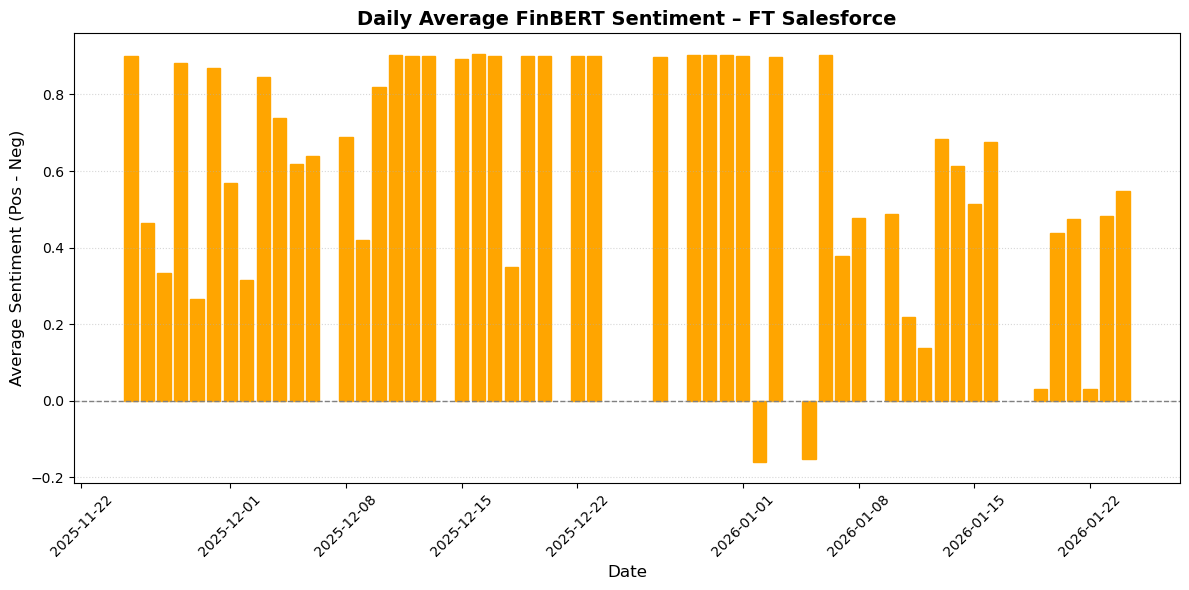

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Load already-scored data
df = pd.read_csv("ft_salesforce_sentiment.csv")

# Parse date
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Compute daily average
daily = (
    df.dropna(subset=["date", "sentiment_score"])
      .groupby(df["date"].dt.date)["sentiment_score"]
      .mean()
      .reset_index()
)

daily["date"] = pd.to_datetime(daily["date"])

# ---- Styled Plot ----
plt.figure(figsize=(12,6))

plt.bar(
    daily["date"],
    daily["sentiment_score"],
    color="orange",      # change color here
    edgecolor="orange"
)

plt.axhline(0, linestyle="--", color="grey", linewidth=1)

plt.title("Daily Average FinBERT Sentiment – FT Salesforce",
          fontsize=14, fontweight="bold")

plt.xlabel("Date", fontsize=12)
plt.ylabel("Average Sentiment (Pos - Neg)", fontsize=12)

plt.xticks(rotation=45)
plt.grid(axis="y", linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()